Airbnb Price Prediction Project
Predicting Airbnb Rental Prices in New York City Using Machine Learning

This project analyzes Airbnb listing data in New York City to identify the factors that influence nightly rental prices and develop machine learning models to predict Airbnb pricing.

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

Load and Explore Dataset

This section loads the Airbnb dataset and explores its structure.

In [5]:

# Read the CSV files into DataFrame
df = pd.read_csv('AB_NYC_2019.csv')

# Show the first 10 rows
print(df.head(10))

# Dataset information
print(df.info())

# Check missing values
print(df.isnull().sum())

     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   
5  5099         Large Cozy 1 BR Apartment In Midtown East     7322   
6  5121                                   BlissArtsSpace!     7356   
7  5178                  Large Furnished Room Near B'way      8967   
8  5203                Cozy Clean Guest Room - Family Apt     7490   
9  5238                Cute & Cozy Lower East Side 1 bdrm     7549   

     host_name neighbourhood_group       neighbourhood  latitude  longitude  \
0         John            Brooklyn          Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan             Midtown  40.75362  -73.9

Data Cleaning

This section handles missing values and removes extreme price outliers to improve model performance.

In [8]:
# Fill missing values
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)
df["name"] = df["name"].fillna("Unknown")
df["host_name"] = df["host_name"].fillna("Unknown")

# Remove extreme outliers
df = df[df["price"] < 1000]

# Create visualization copy
df_visual = df.copy()

# Verify cleaned data
print(df.head())

     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room    149               1                  9  20

Visualization 1 — Distribution of Airbnb Prices

This histogram displays the distribution of Airbnb nightly rental prices.

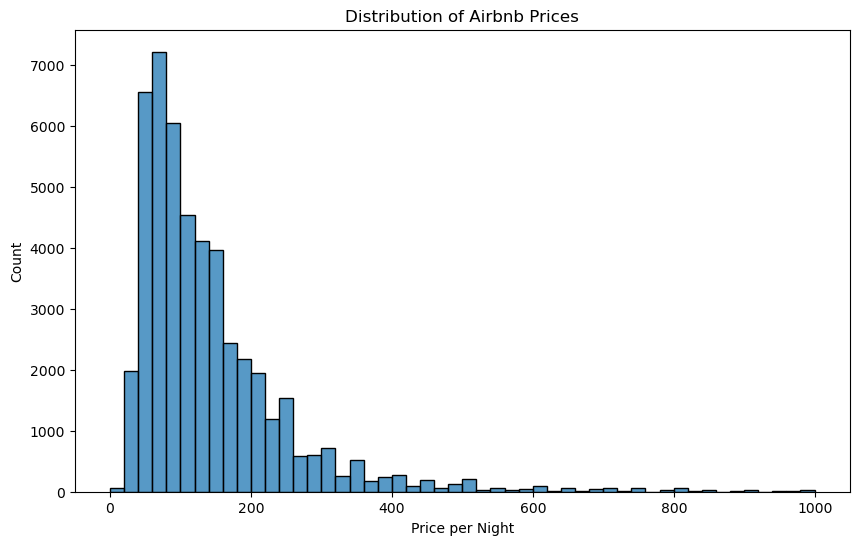

In [11]:

plt.figure(figsize=(10,6))

sns.histplot(df_visual["price"], bins=50)

plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price per Night")
plt.ylabel("Count")

plt.show()

Visualization 2 — Airbnb Prices by Borough

This boxplot compares Airbnb prices across New York City boroughs.

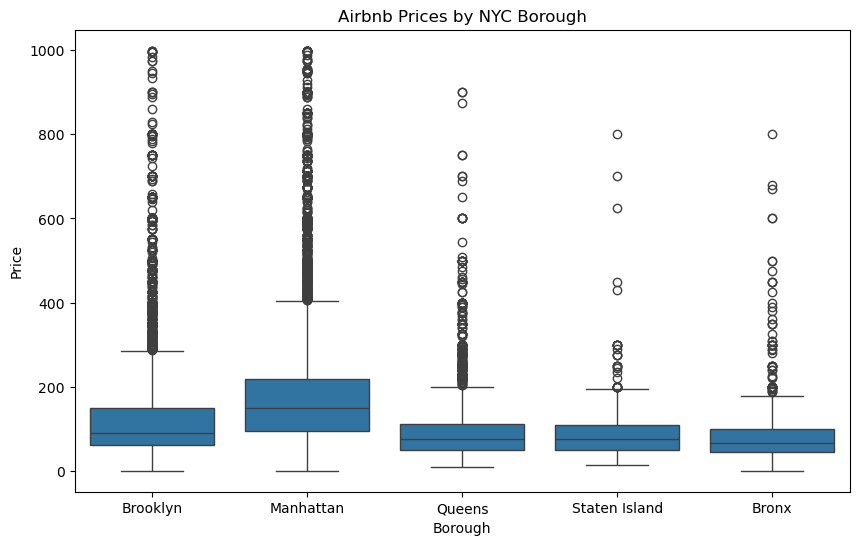

In [14]:

plt.figure(figsize=(10,6))

sns.boxplot(
    x="neighbourhood_group",
    y="price",
    data=df_visual
)

plt.title("Airbnb Prices by NYC Borough")
plt.xlabel("Borough")
plt.ylabel("Price")

plt.show()

Visualization 3 — Average Price by Room Type

This chart compares average Airbnb prices by room type.

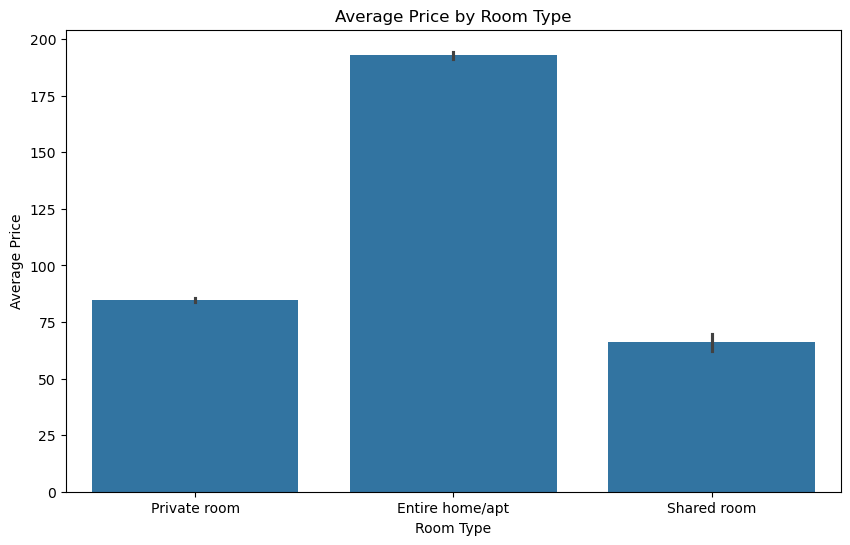

In [17]:


plt.figure(figsize=(10,6))

sns.barplot(
    x="room_type",
    y="price",
    data=df_visual
)

plt.title("Average Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Price")

plt.show()

Visualization 4 — Reviews vs Price

This scatterplot examines the relationship between review counts and Airbnb prices.

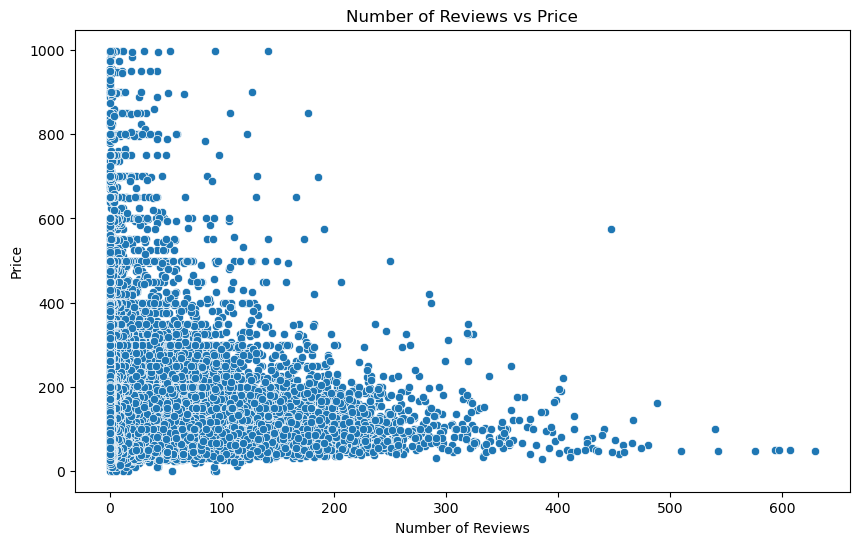

In [20]:

plt.figure(figsize=(10,6))

sns.scatterplot(
    x="number_of_reviews",
    y="price",
    data=df_visual
)

plt.title("Number of Reviews vs Price")
plt.xlabel("Number of Reviews")
plt.ylabel("Price")

plt.show()

Machine Learning Preparation

This section prepares the dataset for machine learning by selecting features and encoding categorical variables.

In [23]:


# MACHINE LEARNING PREPARATION


# Select useful columns

model_df = df[[
    "price",
    "neighbourhood_group",
    "neighbourhood",
    "room_type",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "latitude",
    "longitude"
]].copy()

# Encode categorical variables

le = LabelEncoder()

model_df.loc[:, "neighbourhood_group"] = le.fit_transform(
    model_df["neighbourhood_group"]
)

model_df.loc[:, "neighbourhood"] = le.fit_transform(
    model_df["neighbourhood"]
)

model_df.loc[:, "room_type"] = le.fit_transform(
    model_df["room_type"]
)

# Features

X = model_df.drop("price", axis=1)

# Log transform target variable

y = np.log1p(model_df["price"])

# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X.head())

  neighbourhood_group neighbourhood room_type  minimum_nights  \
0                   1           108         1               1   
1                   2           127         0               1   
2                   2            94         1               3   
3                   1            41         0               1   
4                   2            61         0              10   

   number_of_reviews  reviews_per_month  calculated_host_listings_count  \
0                  9               0.21                               6   
1                 45               0.38                               2   
2                  0               0.00                               1   
3                270               4.64                               1   
4                  9               0.10                               1   

   availability_365  latitude  longitude  
0               365  40.64749  -73.97237  
1               355  40.75362  -73.98377  
2               365  40.80902

Linear Regression Model

This model provides a baseline prediction model for Airbnb pricing.

In [26]:

# LINEAR REGRESSION MODEL

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

# Predict log prices

lr_predictions_log = lr_model.predict(X_test)

# Convert predictions back to normal prices

lr_predictions = np.expm1(lr_predictions_log)

# Convert actual values back

y_test_actual = np.expm1(y_test)

# Metrics

lr_rmse = np.sqrt(
    mean_squared_error(y_test_actual, lr_predictions)
)

lr_mae = mean_absolute_error(
    y_test_actual,
    lr_predictions
)

lr_r2 = r2_score(
    y_test_actual,
    lr_predictions
)

print("LINEAR REGRESSION RESULTS")

print("RMSE:", lr_rmse)

print("MAE:", lr_mae)

print("R2 Score:", lr_r2)

LINEAR REGRESSION RESULTS
RMSE: 91.50252383492983
MAE: 50.381463467091145
R2 Score: 0.28663368234772946


Random Forest Regression Model

This model improves prediction accuracy and identifies important pricing features.

In [29]:

# RANDOM FOREST MODEL

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predict log prices

rf_predictions_log = rf_model.predict(X_test)

# Convert predictions back to normal prices

rf_predictions = np.expm1(rf_predictions_log)

# Convert actual values back

y_test_actual = np.expm1(y_test)

# Metrics

rf_rmse = np.sqrt(
    mean_squared_error(y_test_actual, rf_predictions)
)

rf_mae = mean_absolute_error(
    y_test_actual,
    rf_predictions
)

rf_r2 = r2_score(
    y_test_actual,
    rf_predictions
)

print("RANDOM FOREST RESULTS")

print("RMSE:", rf_rmse)

print("MAE:", rf_mae)

print("R2 Score:", rf_r2)

RANDOM FOREST RESULTS
RMSE: 79.9676125811364
MAE: 43.10900439918608
R2 Score: 0.4551528109302182


Feature Importance Visualization

This chart identifies which variables most influence Airbnb pricing.

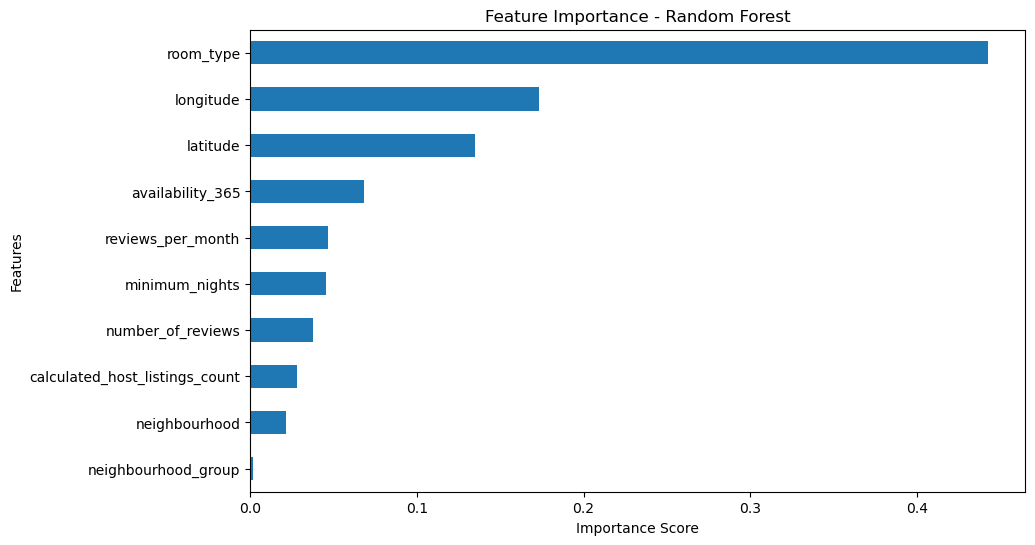

In [32]:

# FEATURE IMPORTANCE CHART

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

plt.figure(figsize=(10,6))

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance - Random Forest")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

Actual vs Predicted Prices

This chart compares actual Airbnb prices to predicted Airbnb prices generated by the Random Forest model.

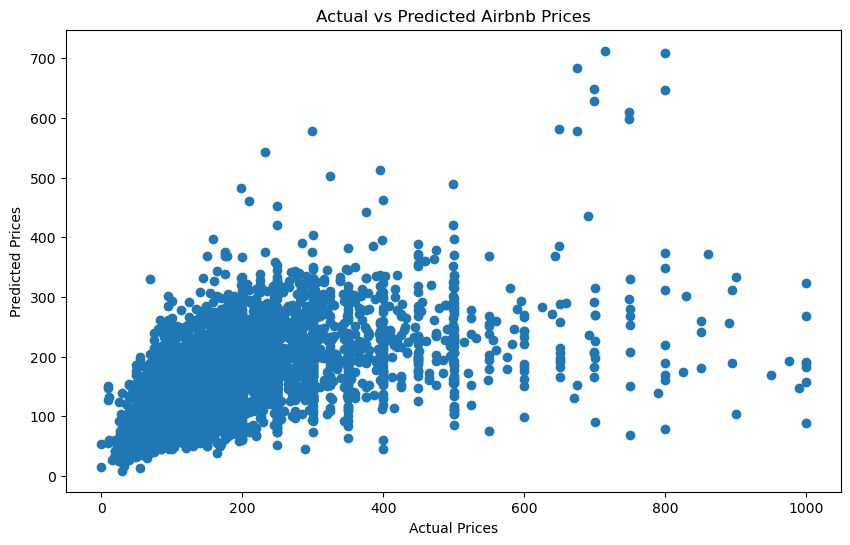

In [35]:

# ACTUAL VS PREDICTED CHART

plt.figure(figsize=(10,6))

plt.scatter(y_test_actual, rf_predictions)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Airbnb Prices")

plt.show()

Sample Prediction Results

This section compares actual Airbnb prices to predicted prices.

In [38]:

# SAMPLE PREDICTIONS

results = pd.DataFrame({
    "Actual Price": y_test_actual,
    "Predicted Price": rf_predictions
})

print(results.head(10))

       Actual Price  Predicted Price
28173          60.0        61.235740
12358         100.0       132.834188
46892          28.0        41.200705
41177          55.0        56.914415
48240         220.0       195.718461
4              80.0       131.954255
44460          48.0        93.144681
6594          107.0       155.289731
3424           89.0        70.455870
46934         189.0       300.907003


User Input Prediction System

This section allows users to enter Airbnb listing information and receive a predicted Airbnb rental price generated by the Random Forest machine learning model.

In [41]:

# USER INPUT PREDICTION SYSTEM

# Display available options

print("Available Neighbourhood Groups:")
print(df["neighbourhood_group"].unique())

print("\nAvailable Room Types:")
print(df["room_type"].unique())

print("\nExample Neighbourhoods:")
print(df["neighbourhood"].unique()[:20])

# =====================================
# USER INPUTS
# =====================================

neighbourhood_group_input = input(
    "\nEnter neighbourhood group: "
)

neighbourhood_input = input(
    "Enter neighbourhood: "
)

room_type_input = input(
    "Enter room type: "
)

minimum_nights_input = int(
    input("Enter minimum nights: ")
)

number_of_reviews_input = int(
    input("Enter number of reviews: ")
)

reviews_per_month_input = float(
    input("Enter reviews per month: ")
)

host_listings_input = int(
    input("Enter host listing count: ")
)

availability_input = int(
    input("Enter availability (days per year): ")
)

latitude_input = float(
    input("Enter latitude: ")
)

longitude_input = float(
    input("Enter longitude: ")
)

# =====================================
# CREATE LABEL ENCODERS
# =====================================

group_encoder = LabelEncoder()
group_encoder.fit(df["neighbourhood_group"])

neighbourhood_encoder = LabelEncoder()
neighbourhood_encoder.fit(df["neighbourhood"])

room_encoder = LabelEncoder()
room_encoder.fit(df["room_type"])

# =====================================
# CLEAN USER INPUTS
# =====================================

neighbourhood_group_input = (
    neighbourhood_group_input.strip().title()
)

neighbourhood_input = (
    neighbourhood_input.strip().title()
)

room_type_input = (
    room_type_input.strip()
)

# =====================================
# VALIDATE INPUTS
# =====================================

valid_input = True

# Validate neighbourhood group

if neighbourhood_group_input not in group_encoder.classes_:
    
    print("\nInvalid neighbourhood group.")
    
    print("Choose from:")
    
    print(group_encoder.classes_)
    
    valid_input = False

# Validate neighbourhood

if neighbourhood_input not in neighbourhood_encoder.classes_:
    
    print("\nInvalid neighbourhood.")
    
    print("Example neighbourhoods:")
    
    print(df["neighbourhood"].unique()[:20])
    
    valid_input = False

# Validate room type

if room_type_input not in room_encoder.classes_:
    
    print("\nInvalid room type.")
    
    print("Choose from:")
    
    print(room_encoder.classes_)
    
    valid_input = False

# =====================================
# ONLY CONTINUE IF INPUTS ARE VALID
# =====================================

if valid_input:

    # Encode inputs
    
    group_encoded = group_encoder.transform(
        [neighbourhood_group_input]
    )[0]

    neighbourhood_encoded = neighbourhood_encoder.transform(
        [neighbourhood_input]
    )[0]

    room_encoded = room_encoder.transform(
        [room_type_input]
    )[0]

    # Create dataframe
    
    user_data = pd.DataFrame({
        "neighbourhood_group": [group_encoded],
        "neighbourhood": [neighbourhood_encoded],
        "room_type": [room_encoded],
        "minimum_nights": [minimum_nights_input],
        "number_of_reviews": [number_of_reviews_input],
        "reviews_per_month": [reviews_per_month_input],
        "calculated_host_listings_count": [host_listings_input],
        "availability_365": [availability_input],
        "latitude": [latitude_input],
        "longitude": [longitude_input]
    })

    # Make prediction
    
    predicted_log_price = rf_model.predict(user_data)

    predicted_price = np.expm1(predicted_log_price)

    # Display result
    
    print("\n=====================================")
    print("PREDICTED AIRBNB PRICE")
    print("=====================================")

    print(
        "Estimated Nightly Price: $",
        round(predicted_price[0], 2)
    )

else:
    
    print("\nPrediction cancelled due to invalid input.")

Available Neighbourhood Groups:
['Brooklyn' 'Manhattan' 'Queens' 'Staten Island' 'Bronx']

Available Room Types:
['Private room' 'Entire home/apt' 'Shared room']

Example Neighbourhoods:
['Kensington' 'Midtown' 'Harlem' 'Clinton Hill' 'East Harlem'
 'Murray Hill' 'Bedford-Stuyvesant' "Hell's Kitchen" 'Upper West Side'
 'Chinatown' 'South Slope' 'West Village' 'Williamsburg' 'Fort Greene'
 'Chelsea' 'Crown Heights' 'Park Slope' 'Windsor Terrace' 'Inwood'
 'East Village']



Enter neighbourhood group:  Manhattan
Enter neighbourhood:  Harlem
Enter room type:  Private room
Enter minimum nights:  2
Enter number of reviews:  50
Enter reviews per month:  1.5
Enter host listing count:  2
Enter availability (days per year):  180
Enter latitude:  48.85
Enter longitude:  -73.665



PREDICTED AIRBNB PRICE
Estimated Nightly Price: $ 67.24
